In [12]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.real_world.preprocess_real import prepare_real_dataset
from src.real_world.train_lr_real import train_lr_real, evaluate_lr_real
from src.real_world.train_mlp_real import train_mlp_real
from src.metrics.evaluation import evaluate_model

In [13]:
# Load data
df = pd.read_csv("diabetes_dataset.csv")
data = prepare_real_dataset(df)

X_train = data["X_train"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]
sens_test = data["sens_test"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nSensitive attribute counts:")
print(sens_test["gender"].value_counts())
print(sens_test["race"].value_counts())


Train shape: (69987, 12)
Test shape: (29995, 12)

Sensitive attribute counts:
gender
Female    17543
Male      12452
Name: count, dtype: int64
race
AfricanAmerican    6113
Caucasian          6060
Asian              6004
Hispanic           5933
Other              5885
Name: count, dtype: int64


In [24]:
# Basic dataset info
print("Dataset shape:", df.shape)

print("\nTarget distribution (diabetes):")
print(df["diabetes"].value_counts())
print(df["diabetes"].value_counts(normalize=True))

print("\nGender distribution:")
print(df["gender"].value_counts())

print("\nRace distribution (raw one-hot):")
race_cols = [c for c in df.columns if c.startswith("race:")]
print(df[race_cols].sum())


Dataset shape: (100000, 18)

Target distribution (diabetes):
diabetes
0    91500
1     8500
Name: count, dtype: int64
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64

Gender distribution:
gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

Race distribution (raw one-hot):
race:AfricanAmerican    20223
race:Asian              20015
race:Caucasian          19876
race:Hispanic           19888
race:Other              19998
dtype: int64


In [26]:
# Basic dataset info
print("Dataset shape:", df.shape)

print("\nTarget distribution (diabetes):")
print(df["diabetes"].value_counts())
print(df["diabetes"].value_counts(normalize=True))

print("\nGender distribution:")
print(df["gender"].value_counts())

print("\nRace distribution (raw one-hot):")
race_cols = [c for c in df.columns if c.startswith("race:")]
print(df[race_cols].sum())


Dataset shape: (100000, 18)

Target distribution (diabetes):
diabetes
0    91500
1     8500
Name: count, dtype: int64
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64

Gender distribution:
gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

Race distribution (raw one-hot):
race:AfricanAmerican    20223
race:Asian              20015
race:Caucasian          19876
race:Hispanic           19888
race:Other              19998
dtype: int64


In [14]:
# Logistic Regression
lr_model = train_lr_real(X_train, y_train)
lr_results = evaluate_lr_real(lr_model, X_test, y_test)

y_pred_lr = lr_results["y_pred"]
accuracy_lr = lr_results["accuracy"]

Epoch 1/20 | Train Loss 0.1309, Acc 0.9567 | Val Loss 0.1102, Acc 0.9646
Epoch 2/20 | Train Loss 0.1030, Acc 0.9659 | Val Loss 0.0986, Acc 0.9682
Epoch 3/20 | Train Loss 0.0947, Acc 0.9678 | Val Loss 0.0939, Acc 0.9688
Epoch 4/20 | Train Loss 0.0902, Acc 0.9695 | Val Loss 0.0900, Acc 0.9691
Epoch 5/20 | Train Loss 0.0867, Acc 0.9703 | Val Loss 0.0875, Acc 0.9701
Epoch 6/20 | Train Loss 0.0844, Acc 0.9708 | Val Loss 0.0869, Acc 0.9706
Epoch 7/20 | Train Loss 0.0832, Acc 0.9714 | Val Loss 0.0858, Acc 0.9712
Epoch 8/20 | Train Loss 0.0828, Acc 0.9715 | Val Loss 0.0856, Acc 0.9720
Epoch 9/20 | Train Loss 0.0824, Acc 0.9715 | Val Loss 0.0845, Acc 0.9714
Epoch 10/20 | Train Loss 0.0819, Acc 0.9716 | Val Loss 0.0854, Acc 0.9710
Epoch 11/20 | Train Loss 0.0817, Acc 0.9718 | Val Loss 0.0849, Acc 0.9714
Epoch 12/20 | Train Loss 0.0812, Acc 0.9718 | Val Loss 0.0844, Acc 0.9715
Epoch 13/20 | Train Loss 0.0815, Acc 0.9719 | Val Loss 0.0843, Acc 0.9713
Epoch 14/20 | Train Loss 0.0814, Acc 0.9719 | V

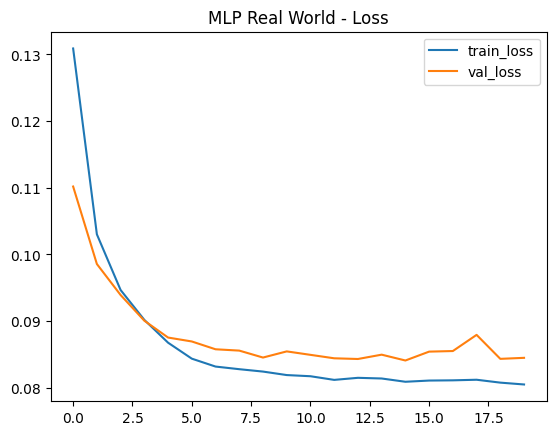

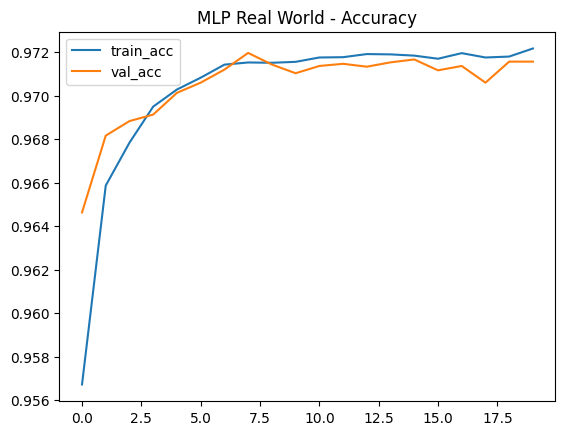

In [15]:
# Neural Network
nn_results = train_mlp_real(
    X_train_s=X_train,
    y_train=y_train,
    X_test_s=X_test,
    y_test=y_test,
    input_dim=X_train.shape[1],
    n_epochs=20,
    lr=0.001,
    plot_training=True
)

nn_pred  = nn_results["y_pred"]
nn_proba = nn_results["probs"]

In [16]:
def compute_group_rates(y_true, y_pred, group, group_name="group"):
    """
    Returns a DataFrame with TPR, FNR, FPR, TNR per group.
    """
    rows = []

    for g in sorted(np.unique(group)):
        idx = group == g

        tp = ((y_pred[idx] == 1) & (y_true[idx] == 1)).sum()
        fn = ((y_pred[idx] == 0) & (y_true[idx] == 1)).sum()
        fp = ((y_pred[idx] == 1) & (y_true[idx] == 0)).sum()
        tn = ((y_pred[idx] == 0) & (y_true[idx] == 0)).sum()

        tpr = tp / (tp + fn + 1e-9)  # sensitivity
        fnr = fn / (tp + fn + 1e-9)  # miss rate
        fpr = fp / (fp + tn + 1e-9)  # false alarm
        tnr = tn / (fp + tn + 1e-9)  # specificity

        rows.append({
            group_name: g,
            "TPR": tpr,
            "FNR": fnr,
            "FPR": fpr,
            "TNR": tnr
        })

    return pd.DataFrame(rows)

In [17]:
def compute_rate_gaps(rate_df):
    """
    Takes output of compute_group_rates
    and returns max–min gaps for each rate.
    """
    gaps = {}
    for col in ["TPR", "FNR", "FPR", "TNR"]:
        gaps[col] = rate_df[col].max() - rate_df[col].min()
    return gaps


In [18]:
lr_rates_gender = compute_group_rates(
    y_true=y_test.values,
    y_pred=y_pred_lr,
    group=sens_test["gender"].values,
    group_name="gender"
)

lr_gaps_gender = compute_rate_gaps(lr_rates_gender)

print("LR – Gender rates")
print(lr_rates_gender)
print("LR – Gender gaps:", lr_gaps_gender)

nn_rates_gender = compute_group_rates(
    y_true=y_test.values,
    y_pred=nn_pred,
    group=sens_test["gender"].values,
    group_name="gender"
)

nn_gaps_gender = compute_rate_gaps(nn_rates_gender)

print("NN – Gender rates")
print(nn_rates_gender)
print("NN – Gender gaps:", nn_gaps_gender)




LR – Gender rates
   gender       TPR       FNR       FPR       TNR
0  Female  0.625480  0.374520  0.007389  0.992611
1    Male  0.623897  0.376103  0.009103  0.990897
LR – Gender gaps: {'TPR': np.float64(0.001582308668991561), 'FNR': np.float64(0.0015823086689571442), 'FPR': np.float64(0.001713916421020343), 'TNR': np.float64(0.0017139164210480118)}
NN – Gender rates
   gender       TPR       FNR       FPR       TNR
0  Female  0.671527  0.328473  0.000369  0.999631
1    Male  0.666399  0.333601  0.000268  0.999732
NN – Gender gaps: {'TPR': np.float64(0.005127886359361233), 'FNR': np.float64(0.0051278863593268165), 'FPR': np.float64(0.00010172051094361139), 'TNR': np.float64(0.00010172051091594803)}


In [19]:
lr_rates_race = compute_group_rates(
    y_true=y_test.values,
    y_pred=y_pred_lr,
    group=sens_test["race"].values,
    group_name="race"
)

lr_gaps_race = compute_rate_gaps(lr_rates_race)

print("LR – Race rates")
print(lr_rates_race)
print("LR – Race gaps:", lr_gaps_race)


nn_rates_race = compute_group_rates(
    y_true=y_test.values,
    y_pred=nn_pred,
    group=sens_test["race"].values,
    group_name="race"
)

nn_gaps_race = compute_rate_gaps(nn_rates_race)

print("NN – Race rates")
print(nn_rates_race)
print("NN – Race gaps:", nn_gaps_race)

LR – Race rates
              race       TPR       FNR       FPR       TNR
0  AfricanAmerican  0.628829  0.371171  0.006837  0.993163
1            Asian  0.609037  0.390963  0.006005  0.993995
2        Caucasian  0.625000  0.375000  0.009386  0.990614
3         Hispanic  0.626747  0.373253  0.008468  0.991532
4            Other  0.634409  0.365591  0.009779  0.990221
LR – Race gaps: {'TPR': np.float64(0.025371274056067317), 'FNR': np.float64(0.025371274056253168), 'FPR': np.float64(0.0037731382773329263), 'TNR': np.float64(0.003773138277335497)}
NN – Race rates
              race       TPR       FNR       FPR       TNR
0  AfricanAmerican  0.679279  0.320721  0.000180  0.999820
1            Asian  0.662083  0.337917  0.000182  0.999818
2        Caucasian  0.671154  0.328846  0.000181  0.999819
3         Hispanic  0.652695  0.347305  0.000552  0.999448
4            Other  0.679570  0.320430  0.000554  0.999446
NN – Race gaps: {'TPR': np.float64(0.026875281694516584), 'FNR': np.float64(0.

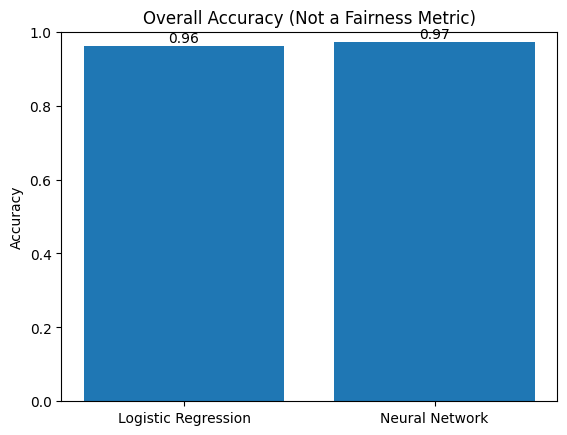

In [20]:


models = ["Logistic Regression", "Neural Network"]
accs = [lr_results["accuracy"], nn_results["accuracy"]]

plt.bar(models, accs)
plt.ylabel("Accuracy")
plt.title("Overall Accuracy (Not a Fairness Metric)")
plt.ylim(0, 1)
for i, v in enumerate(accs):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.show()


In [21]:


def plot_lr_nn_rates(lr_rates, nn_rates, group_col, title):
    """
    lr_rates, nn_rates: DataFrames from compute_group_rates
    group_col: "race" or "gender"
    """

    metrics = ["TPR", "FNR", "FPR", "TNR"]
    groups = lr_rates[group_col].values

    x = np.arange(len(groups))
    width = 0.35

    fig, axes = plt.subplots(1, len(metrics), figsize=(18, 4), sharey=False)
    fig.suptitle(title, fontsize=14)

    for i, metric in enumerate(metrics):
        ax = axes[i]

        lr_vals = lr_rates[metric].values
        nn_vals = nn_rates[metric].values

        bars_lr = ax.bar(x - width/2, lr_vals, width, label="LR")
        bars_nn = ax.bar(x + width/2, nn_vals, width, label="NN")

        ax.set_title(metric)
        ax.set_xticks(x)
        ax.set_xticklabels(groups)
        ax.set_ylim(0, 1)

        # annotate bars
        for bar in bars_lr:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=9)

        for bar in bars_nn:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=9)

        if i == 0:
            ax.legend()

    plt.tight_layout()
    plt.show()


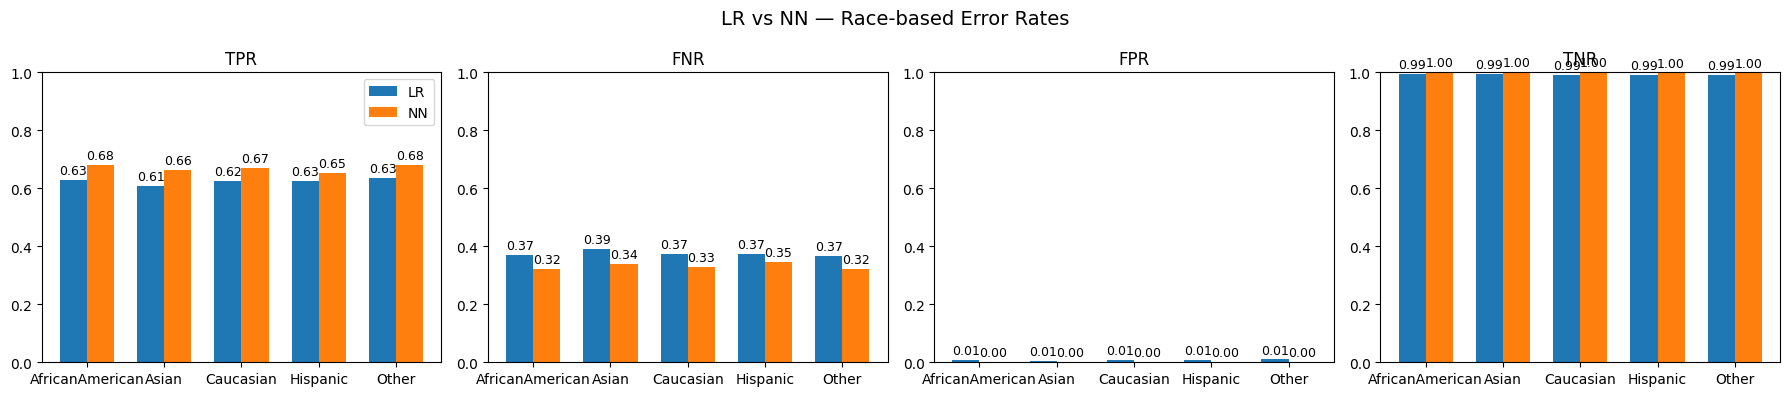

In [22]:
plot_lr_nn_rates(
    lr_rates_race,
    nn_rates_race,
    group_col="race",
    title="LR vs NN — Race-based Error Rates"
)


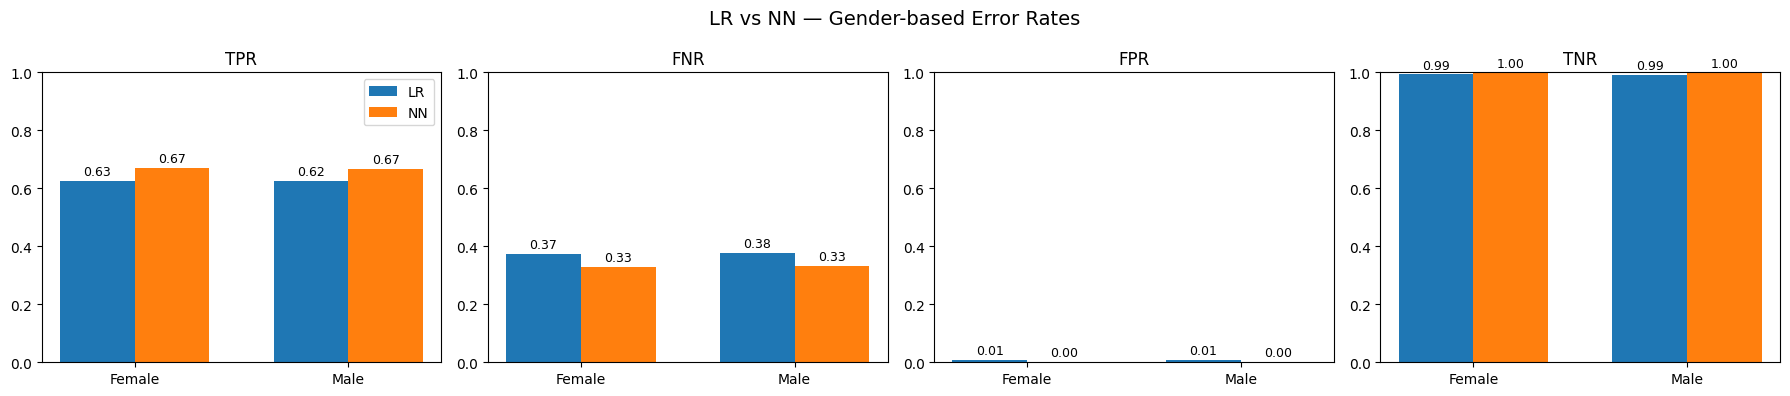

In [23]:
plot_lr_nn_rates(
    lr_rates_gender,
    nn_rates_gender,
    group_col="gender",
    title="LR vs NN — Gender-based Error Rates"
)
